# regularixation technique

regularization makes the model simpler so it can perform better on unseen data.
    
When a model learns too much from training data (overfitting), it performs poorly on new data.

 Regularization controls the model complexity.

we have to achive  regularization  with the help of two technique

Ridge regularization L2

Lasoo Regularization L1

# Lasso Regularization (L1 Regularization):
👉 It is a technique used to reduce overfitting by adding a penalty that can make some coefficients exactly zero

Lasso regularization removes unnecessary features by making their coefficients zero.

Lasso adds penalty based on absolute values of coefficients

✔ Feature selection (very important)
✔ Reduces overfitting
✔ Makes model simple

Lasso (L1) → can make coefficient = 0  ,
Ridge (L2) → only reduces values (not zero)

cost function = loss + λ ∑||W||

loss = sum of squared residual  ,
λ = penalty   ,
W = slope of the curve

# ridge regularization L2 
ridge regression also knows as L2 regularization is an extension to linear regission that intoduces a regularization term to reduce model complexity and help prevent overfiting 

ridge regression is works value/ magnitude of coefficients is almost wqual to zero

cost function = loss + λ ∑||W||^2

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # we have inbalence dataset we wont to scaling 
from sklearn.model_selection import train_test_split

In [27]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\lasso regulaization.csv")
dataset.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [28]:
dataset = dataset.drop(["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"],axis=1)


In [29]:
dataset.head(3)

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2


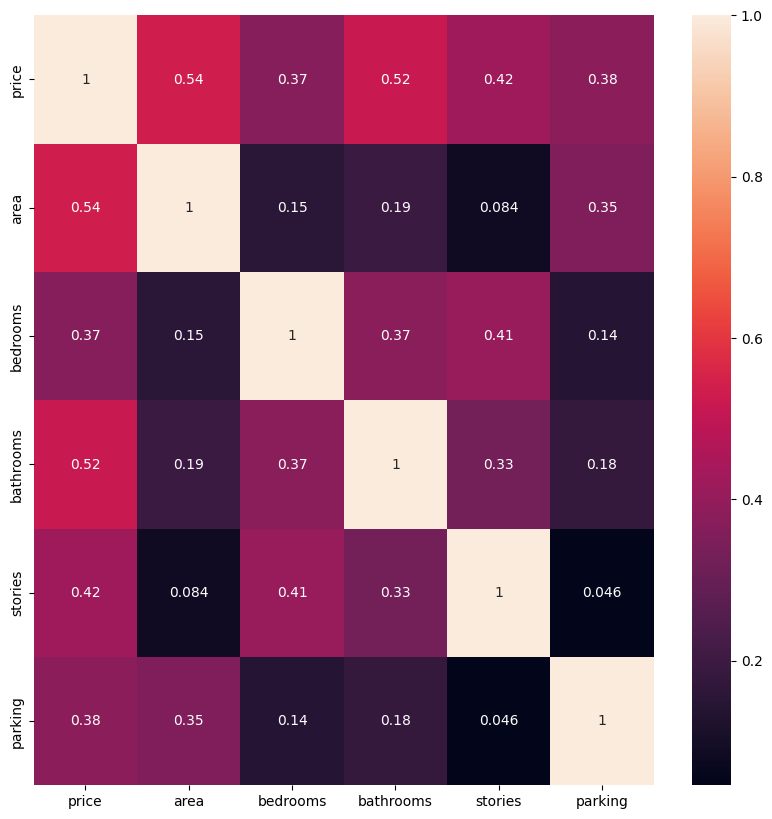

In [30]:
plt.figure(figsize=(10,10))
sns.heatmap(data = dataset.corr(),annot=True)
plt.show()

In [31]:
x = dataset.iloc[:,:-1]
y = dataset["price"]

In [32]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

# linearRegression

In [52]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

100.0

In [59]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

6.980670501379148e-18
1.9096384901519214e-09
2.6420958539347407e-09


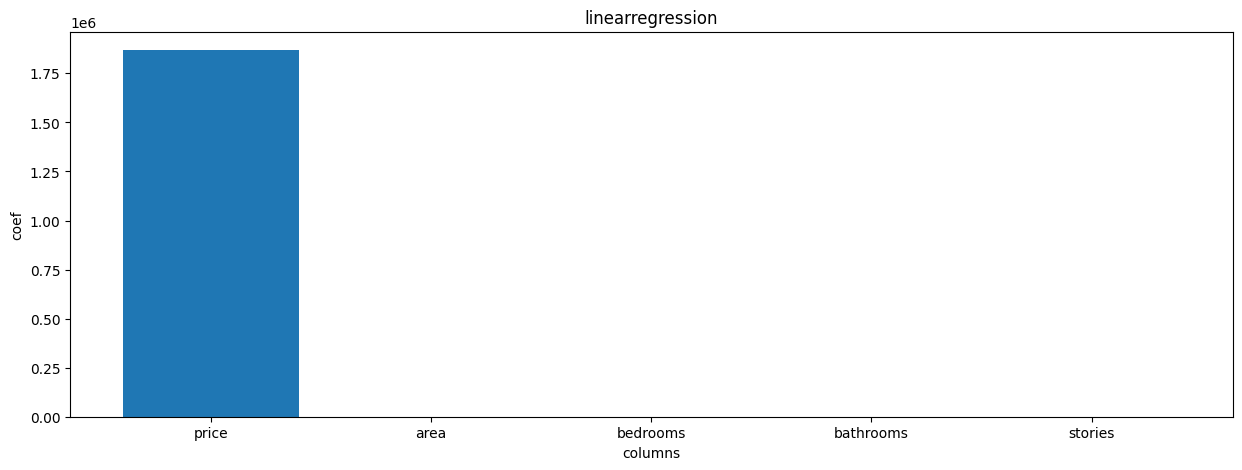

In [53]:
plt.figure(figsize=(15,5))
plt.bar(x.columns,lr.coef_)
plt.title("linearregression")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

# lasso L1

In [66]:
la = Lasso(alpha=0.5)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

99.99999999999065

In [67]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))

0.4724681188637011
0.5298862941819457
0.6873631637378461


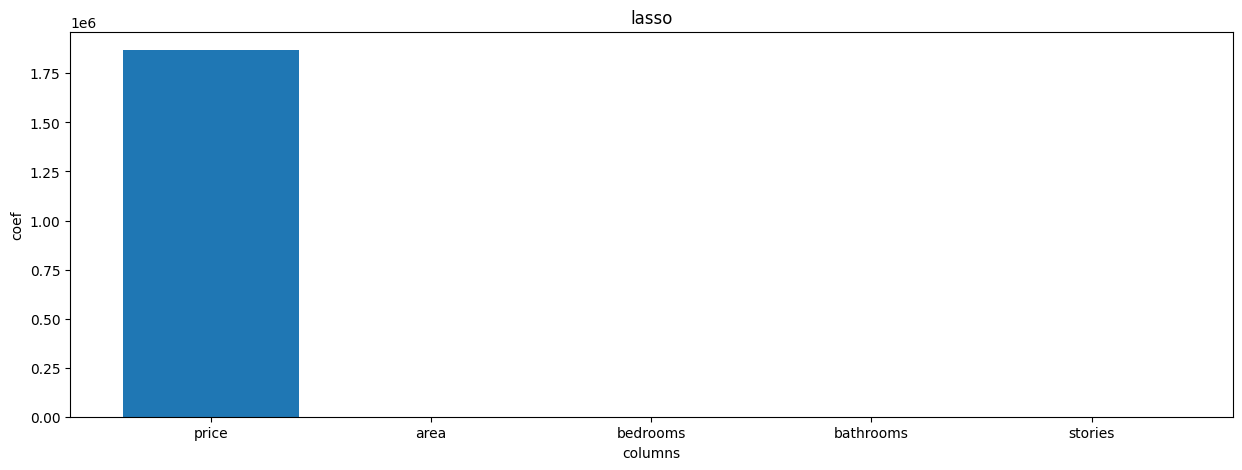

In [46]:
plt.figure(figsize=(15,5))
plt.bar(x.columns,la.coef_)
plt.title("lasso")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

# ridge L2

In [69]:
ri = Ridge(alpha=10) # alpha value used for reduse coeficent or safe model for overfiting 
ri.fit(x_train,y_train)
ri.score(x_test,y_test)

0.9986579679755705

In [73]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

6783395140.343538
60826.863699707064
82361.36922334121


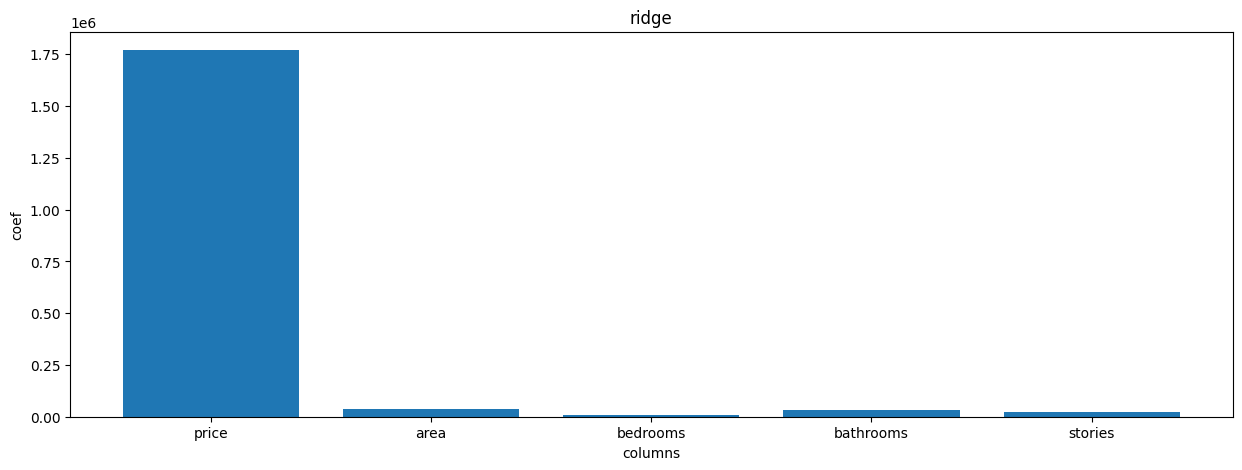

In [49]:
plt.figure(figsize=(15,5))
plt.bar(x.columns,ri.coef_)
plt.title("ridge")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()
